In [69]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np
import os
import cdsapi
import xarray as xr
import zipfile

In [ ]:
# Load ERA5 NetCDF
ds = xr.open_dataset('datasets/era5/era5_fire_20191001_-12.25_142.25/data_stream-oper_stepType-instant.nc', engine='netcdf4')

# Convert from Kelvin to Celsius
ds['t2m'] = ds['t2m'] - 273.15
ds['d2m'] = ds['d2m'] - 273.15

# Compute relative humidity (approx)
rh = 100 * (np.exp((17.625 * ds['d2m']) / (243.04 + ds['d2m'])) /
            np.exp((17.625 * ds['t2m']) / (243.04 + ds['t2m'])))
ds['humidity'] = rh

# Compute wind speed
wind_speed = (ds['u10'] ** 2 + ds['v10'] ** 2) ** 0.5
ds['wind_speed'] = wind_speed

# Convert to DataFrame
df_weather = ds[['t2m', 'd2m', 'msl', 'sst', 'sp', 'humidity', 'wind_speed', 'valid_time']].to_dataframe().reset_index()

df_weather['date'] = pd.to_datetime(df_weather['valid_time']).dt.date
df_weather['hour'] = pd.to_datetime(df_weather['valid_time']).dt.hour

df_weather = df_weather.rename(columns={'latitude': 'lat', 'longitude': 'lon'})
df_weather.head(5)

,valid_time,lat,lon,t2m,d2m,msl,sst,sp,humidity,wind_speed,number,expver,date,hour
18,2019-10-01 02:00:00,-12.00,142.00,33.129242,18.427399,101386.000,NaN,101204.265625,41.805630,5.539679,0,0001,2019-10-01,2
19,2019-10-01 02:00:00,-12.00,142.25,32.529633,18.407867,101405.125,NaN,100980.265625,43.187744,5.891059,0,0001,2019-10-01,2
20,2019-10-01 02:00:00,-12.00,142.50,31.172211,19.046539,101441.625,NaN,100614.265625,48.542118,6.233848,0,0001,2019-10-01,2
21,2019-10-01 02:00:00,-12.25,142.00,33.760101,17.196930,101389.625,NaN,101031.265625,37.345703,5.165632,0,0001,2019-10-01,2
22,2019-10-01 02:00:00,-12.25,142.25,32.887054,17.462555,101411.750,NaN,100925.265625,39.883656,5.462288,0,0001,2019-10-01,2
23,2019-10-01 02:00:00,-12.25,142.50,32.117523,17.845367,101441.375,NaN,100678.265625,42.670673,5.797929,0,0001,2019-10-01,2
24,2019-10-01 02:00:00,-12.50,142.00,33.568695,16.138336,101406.250,NaN,101108.265625,35.293385,5.014513,0,0001,2019-10-01,2
25,2019-10-01 02:00:00,-12.50,142.25,33.752289,15.985992,101417.625,NaN,100985.265625,34.594795,5.146157,0,0001,2019-10-01,2
26,2019-10-01 02:00:00,-12.50,142.50,32.887054,16.480133,101444.250,NaN,100735.265625,37.476685,5.494310,0,0001,2019-10-01,2


<xarray.Dataset> Size: 8kB
Dimensions:     (valid_time: 24, latitude: 3, longitude: 3)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 192B 2019-10-01 ... 2019-10-01T23...
  * latitude    (latitude) float64 24B -12.0 -12.25 -12.5
  * longitude   (longitude) float64 24B 142.0 142.2 142.5
    expver      (valid_time) <U4 384B '0001' '0001' '0001' ... '0001' '0001'
Data variables:
    u10         (valid_time, latitude, longitude) float32 864B -4.824 ... -6.681
    v10         (valid_time, latitude, longitude) float32 864B 1.404 ... 1.077
    d2m         (valid_time, latitude, longitude) float32 864B 19.97 ... 19.3
    t2m         (valid_time, latitude, longitude) float32 864B 29.01 ... 27.83
    msl         (valid_time, latitude, longitude) float32 864B ...
    sst         (valid_time, latitude, longitude) float32 864B ...
    sp          (valid_time, latitude, longitude) float32 864B ...
    humidity    (valid_time, latitude, longitude) float32 864B 58.23 ... 59.81
    wind_speed  (valid_time, latitude, longitude) float32 864B 5.024 ... 6.768
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-04-14T02:51 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
# iterate through later
df = pd.read_csv(r"datasets\FIRMS\MODIS\fire_archive_M-C61_601999.csv")
df.head(5)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,-12.4005,141.7752,321.3,2.6,1.5,2019-10-01,26,Terra,MODIS,60,6.03,300.4,32.7,D,0
1,-12.4045,141.7985,319.1,2.5,1.5,2019-10-01,26,Terra,MODIS,52,6.03,300.1,25.3,D,0
2,-14.2813,143.5160,340.4,1.7,1.3,2019-10-01,26,Terra,MODIS,87,6.03,302.8,74.2,D,0
3,-12.4528,141.7104,321.8,2.6,1.5,2019-10-01,26,Terra,MODIS,0,6.03,300.4,42.1,D,0
4,-12.6828,142.0544,335.7,2.4,1.5,2019-10-01,26,Terra,MODIS,81,6.03,302.9,92.9,D,0


In [5]:
df['acq_time'] = df['acq_time'].astype(str).str.zfill(4)
df['datetime'] = pd.to_datetime(df['acq_date'] + ' ' + df['acq_time'], format='%Y-%m-%d %H%M')
df[['acq_date', 'acq_time']].head(5)

,acq_date,acq_time
0,2019-10-01,0026
1,2019-10-01,0026
2,2019-10-01,0026
3,2019-10-01,0026
4,2019-10-01,0026


In [46]:
df['date'] = pd.to_datetime(df['acq_date']).dt.date
df['lat'] = (df['latitude'] // 0.25) * 0.25
df['lon'] = (df['longitude'] // 0.25) * 0.25
df['hour'] = df['acq_time'].astype(str).str.zfill(4).str[:2].astype(int)


In [47]:
df.head(5)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,bright_t31,frp,daynight,type,datetime,date,lat,lon,fire_label,hour
0,-12.4005,141.7752,321.3,2.6,1.5,2019-10-01,0026,Terra,MODIS,60,...,300.4,32.7,D,0,2019-10-01 00:26:00,2019-10-01,-12.50,141.75,1,0
1,-12.4045,141.7985,319.1,2.5,1.5,2019-10-01,0026,Terra,MODIS,52,...,300.1,25.3,D,0,2019-10-01 00:26:00,2019-10-01,-12.50,141.75,1,0
2,-14.2813,143.5160,340.4,1.7,1.3,2019-10-01,0026,Terra,MODIS,87,...,302.8,74.2,D,0,2019-10-01 00:26:00,2019-10-01,-14.50,143.50,1,0
3,-12.4528,141.7104,321.8,2.6,1.5,2019-10-01,0026,Terra,MODIS,0,...,300.4,42.1,D,0,2019-10-01 00:26:00,2019-10-01,-12.50,141.50,1,0
4,-12.6828,142.0544,335.7,2.4,1.5,2019-10-01,0026,Terra,MODIS,81,...,302.9,92.9,D,0,2019-10-01 00:26:00,2019-10-01,-12.75,142.00,1,0


In [48]:

df_unique = df.drop_duplicates(subset=['lat', 'lon', 'acq_date'], keep=False)
df_unique = df_unique.reset_index()

df_unique.head(5)

,index,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,...,bright_t31,frp,daynight,type,datetime,date,lat,lon,fire_label,hour
0,3,-12.4528,141.7104,321.8,2.6,1.5,2019-10-01,0026,Terra,MODIS,...,300.4,42.1,D,0,2019-10-01 00:26:00,2019-10-01,-12.50,141.50,1,0
1,5,-12.0982,142.3159,322.0,2.4,1.5,2019-10-01,0026,Terra,MODIS,...,296.0,42.2,D,0,2019-10-01 00:26:00,2019-10-01,-12.25,142.25,1,0
2,30,-14.7677,141.7916,324.3,2.3,1.5,2019-10-01,0027,Terra,MODIS,...,308.1,24.0,D,0,2019-10-01 00:27:00,2019-10-01,-15.00,141.75,1,0
3,31,-15.3763,145.2624,325.5,1.3,1.1,2019-10-01,0027,Terra,MODIS,...,299.5,25.5,D,0,2019-10-01 00:27:00,2019-10-01,-15.50,145.25,1,0
4,42,-19.0347,146.6097,310.9,1.0,1.0,2019-10-01,0027,Terra,MODIS,...,300.4,7.7,D,3,2019-10-01 00:27:00,2019-10-01,-19.25,146.50,1,0


In [21]:
print(len(df_unique))

7907


In [ ]:
c = cdsapi.Client()

for idx, row in df_unique.iterrows():
    lat = row['lat']
    lon = row['lon']
    date = pd.to_datetime(row['acq_date'])
    
    year = str(date.year)
    month = f"{date.month:02d}"
    day = f"{date.day:02d}"
    hour = "00:00"  # Or adjust based on acq_time if you want finer control

    area = [
        lat + 0.25, lon - 0.25,  # North, West
        lat - 0.25, lon + 0.25   # South, East
    ]

    output_filename = f"./datasets/era5/era5_fire_{year}{month}{day}_{lat:.2f}_{lon:.2f}.zip"

    print(f"Requesting data for {date.date()} at lat: {lat}, lon: {lon}")

    c.retrieve(
        'reanalysis-era5-single-levels',
        {
            "product_type": "reanalysis",
            "variable": [
                "10m_u_component_of_wind",
                "10m_v_component_of_wind",
                "2m_dewpoint_temperature",
                "2m_temperature",
                "mean_sea_level_pressure",
                "sea_surface_temperature",
                "significant_height_of_combined_wind_waves_and_swell",
                "surface_pressure",
                "total_precipitation"
            ],
            "year": year,
            "month": month,
            "day": day,
            "time": [str(x) + ":00" for x in range(0, 24)],
            "area": area,
            "data_format": "netcdf"
        },
        output_filename
    )

    # Optional: break after a few for testing
    if idx >= 2:
        break

2025-04-14 10:50:23,095 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-04-14 10:50:23,096 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.


Requesting data for 2019-10-01 at lat: -12.5, lon: 141.5


2025-04-14 10:50:24,251 INFO Request ID is c79a3978-3577-4f46-b3a5-e11905b29576
2025-04-14 10:50:24,575 INFO status has been updated to accepted
2025-04-14 10:50:33,992 INFO status has been updated to running
2025-04-14 10:51:16,735 INFO status has been updated to successful


ed61927d4581fb398b4d5a3fd42ed553.zip:   0%|          | 0.00/131k [00:00<?, ?B/s]

Requesting data for 2019-10-01 at lat: -12.25, lon: 142.25


2025-04-14 10:51:22,492 INFO Request ID is 9a40f624-271c-489f-82ed-10889ecfb152
2025-04-14 10:51:22,794 INFO status has been updated to accepted
2025-04-14 10:51:32,603 INFO status has been updated to running
2025-04-14 10:51:57,649 INFO status has been updated to successful


693fbe604e330b161b6a38896f1cfc03.zip:   0%|          | 0.00/131k [00:00<?, ?B/s]

Requesting data for 2019-10-01 at lat: -15.0, lon: 141.75


2025-04-14 10:52:02,352 INFO Request ID is dee02b92-6896-474b-bcad-d3a72d0c3e10
2025-04-14 10:52:02,642 INFO status has been updated to accepted
2025-04-14 10:52:17,348 INFO status has been updated to running
2025-04-14 10:52:37,192 INFO status has been updated to successful


9a4240b1ec92d72a31ccd5fe635fee85.zip:   0%|          | 0.00/131k [00:00<?, ?B/s]

In [49]:
# Mark fire cells
df['fire_label'] = 1
fire_cells = df[['lat', 'lon', 'date', 'fire_label', 'hour']].drop_duplicates()
fire_cells.head(5)

,lat,lon,date,fire_label,hour
0,-12.50,141.75,2019-10-01,1,0
2,-14.50,143.50,2019-10-01,1,0
3,-12.50,141.50,2019-10-01,1,0
4,-12.75,142.00,2019-10-01,1,0
5,-12.25,142.25,2019-10-01,1,0


In [34]:
df_weather.head(5)

,valid_time,lat,lon,t2m,d2m,msl,sst,sp,humidity,wind_speed,number,expver,date
0,2019-10-01,-12.00,142.00,29.006744,19.973663,101553.125,NaN,101370.28125,58.229370,5.024421,0,0001,2019-10-01
1,2019-10-01,-12.00,142.25,28.924713,19.903351,101567.250,NaN,101140.28125,58.252323,5.540645,0,0001,2019-10-01
2,2019-10-01,-12.00,142.50,28.239166,19.926788,101596.500,NaN,100765.28125,60.705788,6.310168,0,0001,2019-10-01
3,2019-10-01,-12.25,142.00,28.952057,19.338898,101567.000,NaN,101205.28125,56.157166,4.414196,0,0001,2019-10-01
4,2019-10-01,-12.25,142.25,28.692291,19.512726,101581.000,NaN,101090.28125,57.628571,4.789584,0,0001,2019-10-01


In [54]:

# Merge with weather
merged = df_weather.merge(fire_cells, on=['lat', 'lon', 'date', 'hour'], how='left')
merged['fire_label'] = merged['fire_label'].fillna(0)  # No fire = 0


In [66]:
len(merged)

216

In [58]:
merged[merged.fire_label == 1].head(5)

,valid_time,lat,lon,t2m,d2m,msl,sst,sp,humidity,wind_speed,number,expver,date,hour,fire_label
4,2019-10-01 00:00:00,-12.25,142.25,28.692291,19.512726,101581.000,NaN,101090.28125,57.628571,4.789584,0,0001,2019-10-01,0,1.0
36,2019-10-01 04:00:00,-12.00,142.00,35.267548,16.501007,101189.625,NaN,101008.87500,32.860130,5.760570,0,0001,2019-10-01,4,1.0
37,2019-10-01 04:00:00,-12.00,142.25,34.425751,16.735382,101238.375,NaN,100814.87500,34.947495,6.443662,0,0001,2019-10-01,4,1.0


In [62]:
features = merged[['t2m', 'd2m', 'msl', 'sp', 'humidity', 'wind_speed']]
labels = merged['fire_label']

In [63]:
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

def seq(data, labels, window=7):
    x,y=[],[]
    for i in range(len(data)-window):
        x.append(data[i:i+window])
        y.append(labels[i+window])
    return np.array(x), np.array(y)

x, y = seq(features_scaled, labels)

In [1]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

model = Sequential([
    LSTM(64, input_shape=(x.shape[1], x.shape[2])),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, batch_size=16, validation_data=(x_test, y_test))

NameError: name 'train_test_split' is not defined

In [68]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)


((array([0., 1.]), array([165,   2])), (array([0.]), array([42])))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        42

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



c:\Users\olive\cs5131proj\venv\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


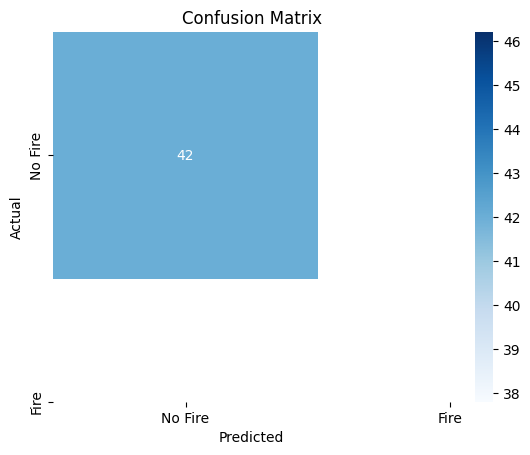

In [67]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_prob = model.predict(x_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No Fire", "Fire"], yticklabels=["No Fire", "Fire"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
